In [324]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Loading the dataset

In [325]:
df = pd.read_csv(r"C:\Users\Sumit\OneDrive\Desktop\LUCY\Dataset\Lucy_english_dataset.csv")

In [326]:
selected_emotions = ["happiness", "sadness", "anger"]
df = df[df["emotion"].isin(selected_emotions)]

In [327]:
emotion_map = {
    "happiness": "happy",
    "sadness": "sad",
    "anger": "angry"
}

df["emotion"] = df["emotion"].map(emotion_map)

In [328]:
df.head()

,text,emotion
5,"I, for one, am thrilled that Christ works outs...",happy
8,i have personally experienced this gut wrenchi...,sad
16,i started to feel shaky like i was about to ha...,sad
20,i feel reassured by the content and consult my...,happy
23,Once I had to go home on foot at 5 a.m. I had ...,sad


### EDA 

In [329]:
df.info()

<class 'pandas.DataFrame'>
Index: 29999 entries, 5 to 106352
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   text     29999 non-null  str  
 1   emotion  29999 non-null  str  
dtypes: str(2)
memory usage: 703.1 KB


In [330]:
df.isnull().sum()

text       0
emotion    0
dtype: int64

In [331]:
df.shape

(29999, 2)

In [332]:
df.describe()

,text,emotion
count,29999,29999
unique,25931,3
top,"“ not afraid of tomorrow, for I have seen yest...",happy
freq,15,10000


In [333]:
df.duplicated().sum()

np.int64(4063)

In [334]:
df.duplicated(subset=["text"]).sum()

np.int64(4068)

In [335]:
df.groupby("text")["emotion"].nunique().sort_values(ascending=False).head()

text
Will do                                                                                                                                                                          2
Why not ?                                                                                                                                                                        2
Thanks                                                                                                                                                                           2
This sucks . I hate buying lingerie . Okay , just find something and get out of here . Alright , these are fine . Oh , no , don ’ t come over here , don ’ t come over here .    2
Certainly not .                                                                                                                                                                  2
Name: emotion, dtype: int64

In [336]:
df['emotion'].value_counts()

emotion
happy    10000
angry    10000
sad       9999
Name: count, dtype: int64

### Removing Duplicates 

In [337]:
df = df.drop_duplicates()

In [338]:
df.duplicated().sum()

np.int64(0)

### Removing the 2 conflicting texts

In [339]:
valid_texts = df.groupby("text")["emotion"].nunique()
valid_texts = valid_texts[valid_texts == 1].index

df = df[df["text"].isin(valid_texts)]

In [340]:
df.shape

(25926, 2)

In [341]:
df.value_counts().sum()

np.int64(25926)

In [342]:
df.groupby("text")["emotion"].nunique().sort_values(ascending=False).head()

text
!! ... maybe they took one look at you and said &quot;That's our girl!&quot;                                                1
" Do n't be cross with Jenny , " James said almost reading her mind .                                                       1
" Don't be cross with Jenny , " James said almost reading her mind .                                                        1
" She looked fondly at Anne ` s bright eyes and happy face .                                                                1
$4 lonestar pitchers at ? If only I wasn't still recovering from last weekend's bout of irresponsible gluten consumption    1
Name: emotion, dtype: int64

### Visulizing The data

<Axes: xlabel='emotion'>

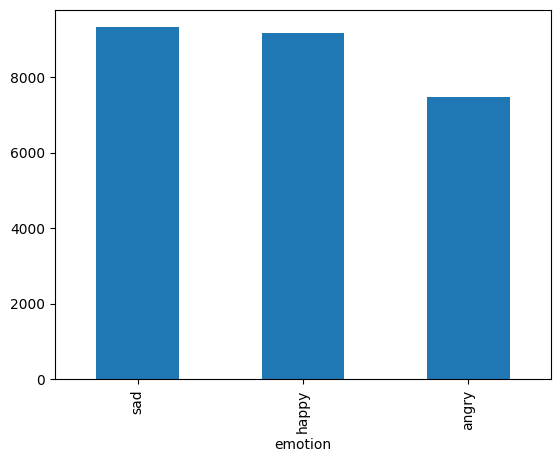

In [343]:
df['emotion'].value_counts().plot(kind='bar')

In [344]:
df["text_length"] = df["text"].apply(len)

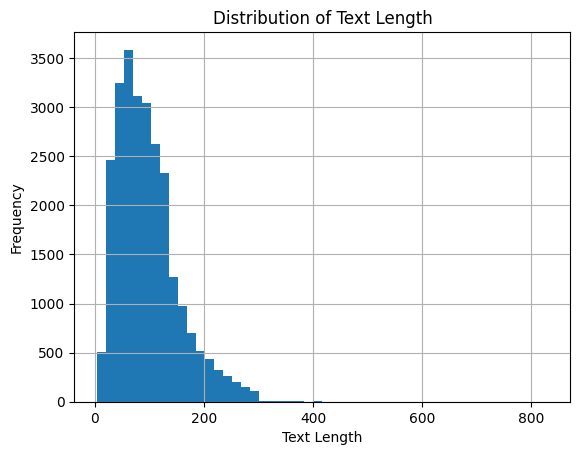

In [345]:
df["text_length"].hist(bins=50)
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.title("Distribution of Text Length")
plt.show()

### Test Train Split

In [346]:
X = df['text']
y = df['emotion']

In [347]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42,stratify=y)

### TF - IDF VECTORIZATION

In [348]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1,2),
    max_features=30000,
    min_df=3,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [349]:
X_train_tfidf.shape


(20740, 11177)

In [350]:
X_test_tfidf.shape

(5186, 11177)

In [351]:
len(vectorizer.vocabulary_)

11177

### Checking for empty veector 

In [352]:
(X_train_tfidf.sum(axis =1) ==0).sum()

np.int64(38)

### Model Selection and training

In [353]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    solver='saga',
    random_state=42,
    C=0.5,
    
)

model.fit(X_train_tfidf,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.5
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [354]:
y_predict = model.predict(X_test_tfidf)

### Accuracy and Classification Report 

In [355]:
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

accuracy_score(y_test,y_predict)


0.8357115310451215

In [356]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

       angry       0.92      0.81      0.86      1492
       happy       0.86      0.83      0.85      1831
         sad       0.76      0.86      0.81      1863

    accuracy                           0.84      5186
   macro avg       0.85      0.83      0.84      5186
weighted avg       0.84      0.84      0.84      5186



In [357]:
model.score(X_train_tfidf,y_train)

0.9050144648023144